# Data Inspection: FracTracker Data Centers and Political Data

## DSCI 591 Capstone: Data Center Impact Explorer

* *Jillian Kunze*
* *Andrea MacGregor*
* *Anna Grace*
* *Morgan Murphy*

Preliminary inspection and exploration of primary data centers dataset and political datasets. Some of the charts created were used in the launch presentation.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

### 1. FracTrackers Data Center Data 

Data from the [FracTracker Alliance U.S. Data Centers Tracker](https://experience.arcgis.com/experience/5a4d072ad01449bba5698a80103fb909/page/About).

In [3]:
file_path = "./Data/FracTrackers_Data_Centers_Database.xlsx"
df = pd.read_excel(file_path)
df.head()

,facility_name,address,city,state,zip,county,lat,long,status,location_confidence,...,info_source_1,info_source_2,info_source_3,info_source_4,info_source_5,info_source_6,info_source_7,info_source_8,date_created,date_updated
0,Global Stack Data Center,NaN,NaN,NaN,NaN,Napa,38.585007,-122.58886,Proposed,Medium,...,https://www.datacenterdynamics.com/en/news/dev...,https://calistoga.civicweb.net/document/116181...,NaN,NaN,NaN,NaN,NaN,NaN,06/29/2026,06/29/2026
1,Stak Energy Data Center,"Dalton Hwy, 26 miles south of Deadhorse",North Slope Borough,AK,NaN,North Slope,69.900710,-148.81477,Proposed,Medium,...,https://www.datacenterdynamics.com/en/news/sta...,https://www.cbc.ca/news/canada/north/yukon-ala...,NaN,NaN,NaN,NaN,NaN,NaN,05/20/2026,06/24/2026
2,Prudhoe Bay Data Center,Dalton Hwy,Prudhoe Bay,AK,99734.0,North Slope,70.184780,-148.44000,Operating,Medium,...,https://www.fn-digital.com/data-center,https://www.datacenterdynamics.com/en/news/sta...,NaN,NaN,NaN,NaN,NaN,NaN,05/20/2026,05/20/2026
3,Grant County Data Center,"Just outside the city limits of Sheridan, Arka...",Sheridan,AK,72150.0,Grant,34.306500,-92.40450,Proposed,Low,...,https://www.deltaplexnews.com/local-news/data-...,https://www.southarkansasreckoning.com/grant-c...,https://www.kark.com/news/local-news/people-pr...,https://arktimes.com/arkansas-blog/2025/11/12/...,https://www.kark.com/news/state-news/grant-cou...,NaN,NaN,NaN,04/28/2026,04/28/2026
4,Project Marvel,Rock Mountain Lake Rd,Bessemer,AL,35022.0,Jefferson,33.342000,-87.03410,Proposed,High,...,https://www.datacenterdynamics.com/en/news/700...,https://www.youtube.com/watch?v=ICSrvQ7meow&ab...,https://www.al.com/news/2025/06/14-billion-pro...,https://www.wbrc.com/2025/09/14/bessemer-resid...,https://www.wbrc.com/2025/11/19/bessemer-city-...,https://www.datacenterdynamics.com/en/news/ala...,https://abc3340.com/news/abc-3340-news-iteam/b...,https://insideclimatenews.org/news/13112025/pr...,09/16/2025,03/13/2026


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1593 entries, 0 to 1592
Data columns (total 44 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   facility_name              1591 non-null   object 
 1   address                    1530 non-null   object 
 2   city                       1588 non-null   object 
 3   state                      1592 non-null   object 
 4   zip                        1541 non-null   float64
 5   county                     1591 non-null   object 
 6   lat                        1593 non-null   float64
 7   long                       1593 non-null   float64
 8   status                     1593 non-null   object 
 9   location_confidence        1588 non-null   object 
 10  purpose                    72 non-null     object 
 11  operator_name              882 non-null    object 
 12  tenant                     1 non-null      object 
 13  mw                         595 non-null    objec

In [12]:
print("Number of items in data set:", df.shape[0])
print("Number of unique facility names in dataset:", df["facility_name"].nunique())
print("Note that facility names are not unique identifiers (e.g., 'Microsoft Data Centers' is repeated for data centers in different locations)")
print()

# Show duplicated facility names (https://stackoverflow.com/questions/22904523/select-rows-with-duplicate-observations-in-pandas)
df[df.duplicated("facility_name", keep = False) == True].tail()

Number of items in data set: 1593
Number of unique facility names in dataset: 1445
Note that facility names are not unique identifiers (e.g., 'Microsoft Data Centers' is repeated for data centers in different locations)



,facility_name,address,city,state,zip,county,lat,long,status,location_confidence,...,info_source_1,info_source_2,info_source_3,info_source_4,info_source_5,info_source_6,info_source_7,info_source_8,date_created,date_updated
1567,Data center,5825 W. Hope Ave,Milwaukee,WI,53216.0,Milwaukee,43.09332,-87.9846,Proposed,High,...,https://www.datacenterdynamics.com/en/news/for...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,05/12/2026,05/12/2026
1569,Project Lighthouse,Between Lake and Dixie Rds,Port Washington,WI,53074.0,Ozaukee,43.44933,-87.8525,Approved/Permitted/Under construction,Medium,...,https://www.datacenterdynamics.com/en/news/clo...,https://www.datacenterdynamics.com/en/news/van...,https://www.fox6now.com/news/port-washington-d...,https://www.jsonline.com/story/communities/nor...,https://www.widatacenterfacts.org/communities/...,https://www.widatacenterfacts.org/communities/...,https://www.widatacenterfacts.org/communities/...,https://www.datacenterdynamics.com/en/news/van...,08/06/2025,06/29/2026
1572,Microsoft Data Center,11508 Braun Rd,Sturtevant,WI,53178.0,Racine,42.68763,-87.9269,Proposed,High,...,https://biztimes.com/microsoft-gets-approval-f...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,09/19/2025,09/19/2025
1573,Microsoft Data Center,12721 Louis Sorenson Rd,Sturtevant,WI,53177.0,Racine,42.70384,-87.9382,Proposed,High,...,https://www.datacenterdynamics.com/en/news/mic...,https://www.datacenterdynamics.com/en/news/mic...,https://www.jsonline.com/story/money/real-esta...,NaN,NaN,NaN,NaN,NaN,09/20/2025,09/20/2025
1587,Meta Data Center,High Plains Business Park,Cheyenne,WY,82007.0,Laramie,41.08515,-104.8330,Proposed,Medium,...,https://www.datacenterdynamics.com/en/news/met...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,08/11/2025,08/11/2025


In [19]:
print("Number of zip codes covered in dataset:", df["zip"].nunique())
print("Number of zip codes in U.S.: 41,554 (note that some of these zip codes are unique to e.g. a company campus)")
print("So, the data centers are concentrated in certain locations")

Number of zip codes covered in dataset: 873
Number of zip codes in U.S.: 41,554 (note that some of these zip codes are unique to e.g. a company campus)
So, the data centers are concentrated in certain locations


In [25]:
print(df.columns)
location_columns = ['facility_name', 'address', 'city', 'state', 'zip', 'county', 'lat', 'long', 'location_confidence']
other_columns = ['status', 'purpose', 'operator_name', 'tenant', 'mw', 'sizerank', 'power_source', 'dedicated_power_plant',
       'number_of_generators', 'number_of_buildings', 'cooling_source', 'cooling_type', 'facility_size_sqft', 'property_size_acres',
       'project_cost', 'expected_date_online', 'community_pushback', 'advocacy_information', 'resistance_status', 'nda', 'other_info']

# omitting stuff like website URLs

Index(['facility_name', 'address', 'city', 'state', 'zip', 'county', 'lat',
       'long', 'status', 'location_confidence', 'purpose', 'operator_name',
       'tenant', 'mw', 'sizerank', 'power_source', 'dedicated_power_plant',
       'number_of_generators', 'number_of_buildings', 'cooling_source',
       'cooling_type', 'facility_size_sqft', 'property_size_acres',
       'project_cost', 'expected_date_online', 'community_pushback',
       'advocacy_information', 'resistance_status', 'nda',
       'community_group_website_1', 'community_group_website_2',
       'petition_url', 'other_info', 'information_source', 'info_source_1',
       'info_source_2', 'info_source_3', 'info_source_4', 'info_source_5',
       'info_source_6', 'info_source_7', 'info_source_8', 'date_created',
       'date_updated'],
      dtype='object')


In [28]:
df[location_columns].isnull().sum()

facility_name           2
address                63
city                    5
state                   1
zip                    52
county                  2
lat                     0
long                    0
location_confidence     5
dtype: int64

In [29]:
df[other_columns].isnull().sum()

status                      0
purpose                  1521
operator_name             711
tenant                   1592
mw                        998
sizerank                    0
power_source             1477
dedicated_power_plant    1561
number_of_generators     1580
number_of_buildings      1400
cooling_source           1544
cooling_type             1537
facility_size_sqft        643
property_size_acres       663
project_cost             1326
expected_date_online     1465
community_pushback          1
advocacy_information     1529
resistance_status        1514
nda                      1582
other_info                989
dtype: int64

In [30]:
other_columns_useful = ['status', 'operator_name', 'mw', 'sizerank',  'facility_size_sqft', 
                        'property_size_acres', 'community_pushback',  'other_info']
# some of these still have a decent number of nulls, so usefulness might be limited 

other_columns_not_enough_info = ['purpose', 'tenant', 'power_source', 'dedicated_power_plant', 'number_of_generators', 'number_of_buildings', 
                                 'cooling_source', 'cooling_type', 'project_cost', 'expected_date_online', 'advocacy_information', 
                                 'resistance_status', 'nda']
# defining this as things with more than 1000s nulls

In [32]:
df['status'].value_counts()

status
Proposed                                 726
Operating                                531
Approved/Permitted/Under construction    159
Cancelled                                 61
Expanding                                 59
Suspended                                 57
Name: count, dtype: int64

In [38]:
print("Unique operator names:", df['operator_name'].nunique())
df['operator_name'].value_counts().head()

Unique operator names: 458


operator_name
Amazon            85
Microsoft         63
Google            36
Meta              24
Digital Realty    20
Name: count, dtype: int64

In [41]:
df['sizerank'].value_counts()

sizerank
Unknown                    890
Hyperscale (100-999 MW)    341
Medium (11-50 MW)          115
Mega campus (>1,000 MW)    110
Small (0-10 MW)            101
Large (51-99 MW)            35
Hyperscale (101-999 MW)      1
Name: count, dtype: int64

In [42]:
df['community_pushback'].value_counts()

community_pushback
Unknown    1336
Yes         254
Yes           2
Name: count, dtype: int64

In [44]:
print("Unique other info:", df['other_info'].nunique())
df['other_info'].value_counts()

Unique other info: 422


other_info
Computer Center                                                                                                             51
Shown as "Storage Warehouse"                                                                                                38
Project covers more than one parcel, the acreage represents the combined acreage                                            33
This project covers multiple parcels. The total acreage has been represented here.                                          33
FULLY REGULATED                                                                                                             12
                                                                                                                            ..
Project rejected before full plan even proposed                                                                              1
Has secured commitments for 100% renewable energy and recycled water for cooling, with backup genera

In [47]:
# Look at numeric columns: mw, facility_size_sqft, property_size_acres
df[['mw', 'facility_size_sqft', 'property_size_acres']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1593 entries, 0 to 1592
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   mw                   595 non-null    object 
 1   facility_size_sqft   950 non-null    object 
 2   property_size_acres  930 non-null    float64
dtypes: float64(1), object(2)
memory usage: 37.5+ KB


In [3]:
# Facility size has commas in the numbers - need to strip out to be able to convert from string to number 
# https://stackoverflow.com/questions/13682044/remove-unwanted-parts-from-strings-in-a-column
df['facility_size_sqft'] = df['facility_size_sqft'].str.replace(",", "", regex = True)
df[['facility_size_sqft']]

,facility_size_sqft
0,NaN
1,NaN
2,NaN
3,1000000
4,4500000
...,...
1588,NaN
1589,NaN
1590,NaN
1591,NaN


In [4]:
# Convert objects to numeric 
df['mw'] = pd.to_numeric(df['mw'], errors = "coerce")
df['facility_size_sqft'] = pd.to_numeric(df['facility_size_sqft'], errors = "coerce")

df[['mw', 'facility_size_sqft', 'property_size_acres']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1593 entries, 0 to 1592
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   mw                   505 non-null    float64
 1   facility_size_sqft   950 non-null    float64
 2   property_size_acres  930 non-null    float64
dtypes: float64(3)
memory usage: 37.5 KB


array([[<Axes: title={'center': 'mw'}>,
        <Axes: title={'center': 'facility_size_sqft'}>],
       [<Axes: title={'center': 'property_size_acres'}>, <Axes: >]],
      dtype=object)

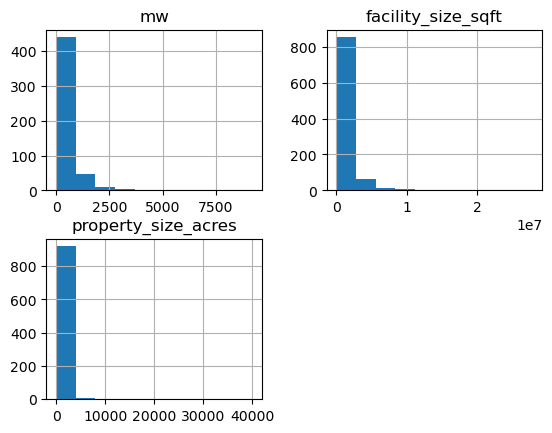

In [5]:
df[['mw', 'facility_size_sqft', 'property_size_acres']].hist()

Text(0.5, 0, 'Megawattage')

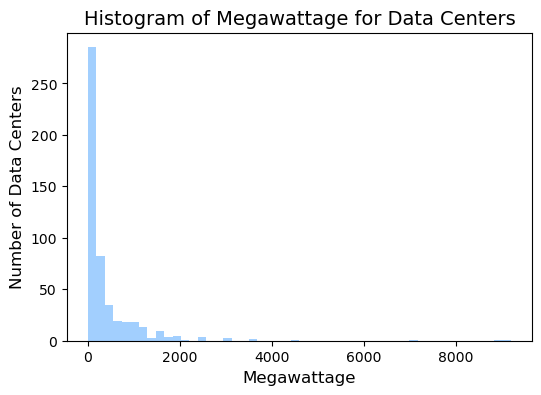

In [23]:
plt.figure(figsize = (6,4))
df['mw'].hist(bins = 50, grid = False, color = "#a2cffe")
plt.title("Histogram of Megawattage for Data Centers", fontsize = 14)
plt.ylabel("Number of Data Centers", fontsize = 12)
plt.xlabel("Megawattage", fontsize = 12)

Text(0.5, 0, 'Facility Size (square feet)')

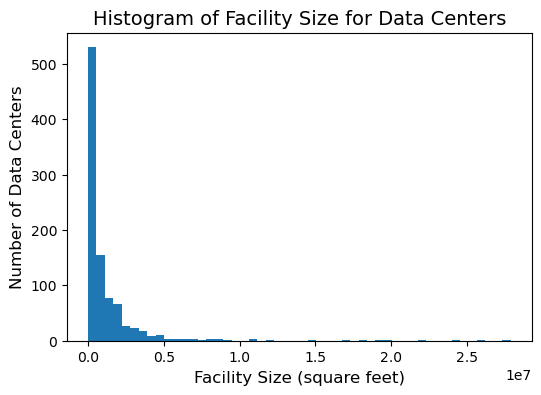

In [20]:
plt.figure(figsize = (6,4))
df['facility_size_sqft'].hist(bins = 50, grid = False)
plt.title("Histogram of Facility Size for Data Centers", fontsize = 14)
plt.ylabel("Number of Data Centers", fontsize = 12)
plt.xlabel("Facility Size (square feet)", fontsize = 12)

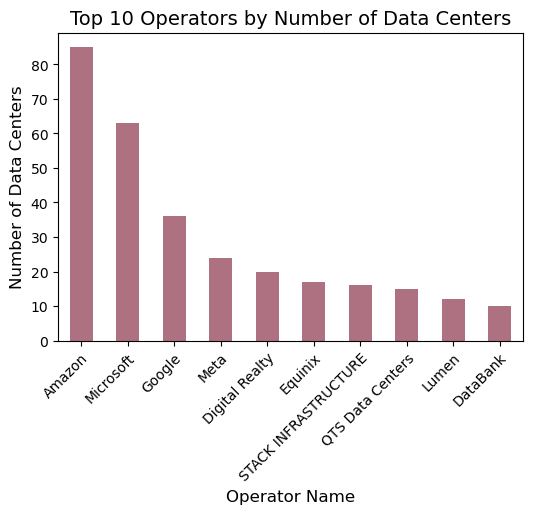

In [22]:
plt.figure(figsize = (6,4))
df['operator_name'].value_counts().head(10).plot(kind = "bar", color = "#ae7181")
plt.title("Top 10 Operators by Number of Data Centers", fontsize = 14)
plt.ylabel("Number of Data Centers", fontsize = 12)
plt.xlabel("Operator Name", fontsize = 12)
plt.xticks(rotation = 45, rotation_mode = "anchor", ha = "right")
plt.show()

It would also be interesting to see which companies are most prevalent in the top states in the dataset; I'll visualize that below for the pitch presentation.

In [104]:
from seaborn import objects as so
import plotly.express as px

In [105]:
df["state"].value_counts().head()

state
VA    458
TX    200
GA    178
PA    104
OH     61
Name: count, dtype: int64

In [106]:
df_top_states = df[df["state"].isin(["VA", "TX", "GA", "PA", "OH"])]

# top companies in these states
df_top_states["operator_name"].value_counts().head(10)

operator_name
Amazon                  69
Microsoft               35
Google                  21
Digital Realty          17
Equinix                 16
STACK INFRASTRUCTURE    16
Lumen                   12
QTS Data Centers        12
Meta                     8
DataBank                 8
Name: count, dtype: int64

In [107]:
org_list = ["Amazon", "Microsoft", "Google", "Digital Realty", "Equinix"]
df_top_states.loc[~df_top_states['operator_name'].isin(org_list), 'operator_name'] = "Other"

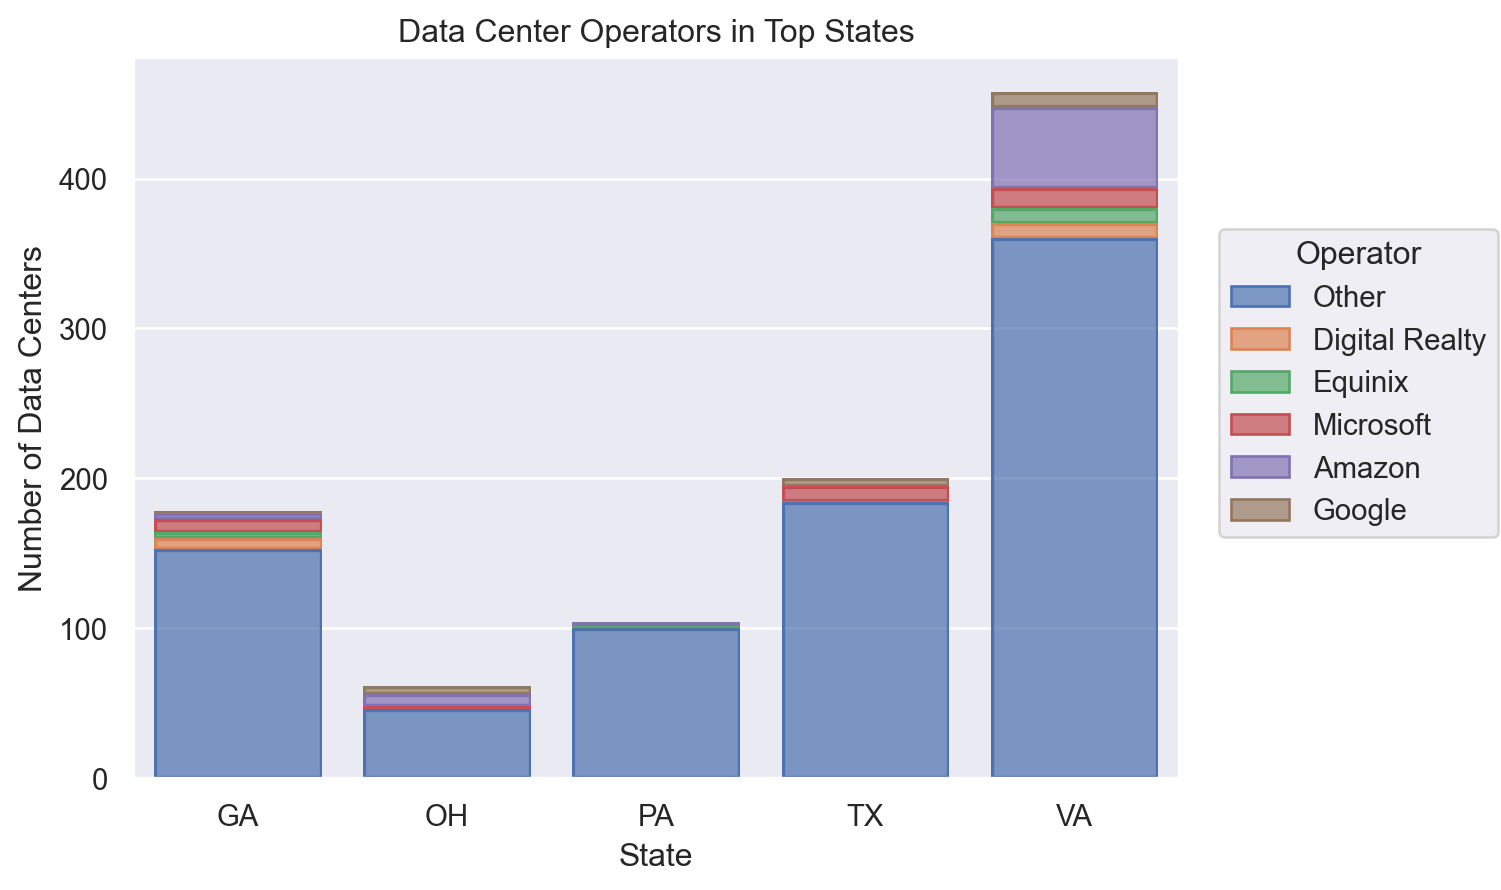

In [108]:
# Seaborn version
# https://seaborn.pydata.org/generated/seaborn.objects.Stack.html

plot1 = so.Plot(df_top_states, x = "state", color = "operator_name").add(so.Bar(), so.Count(), so.Stack())
plot1.label(x = "State", y = "Number of Data Centers", title = "Data Center Operators in Top States", color = "Operator")

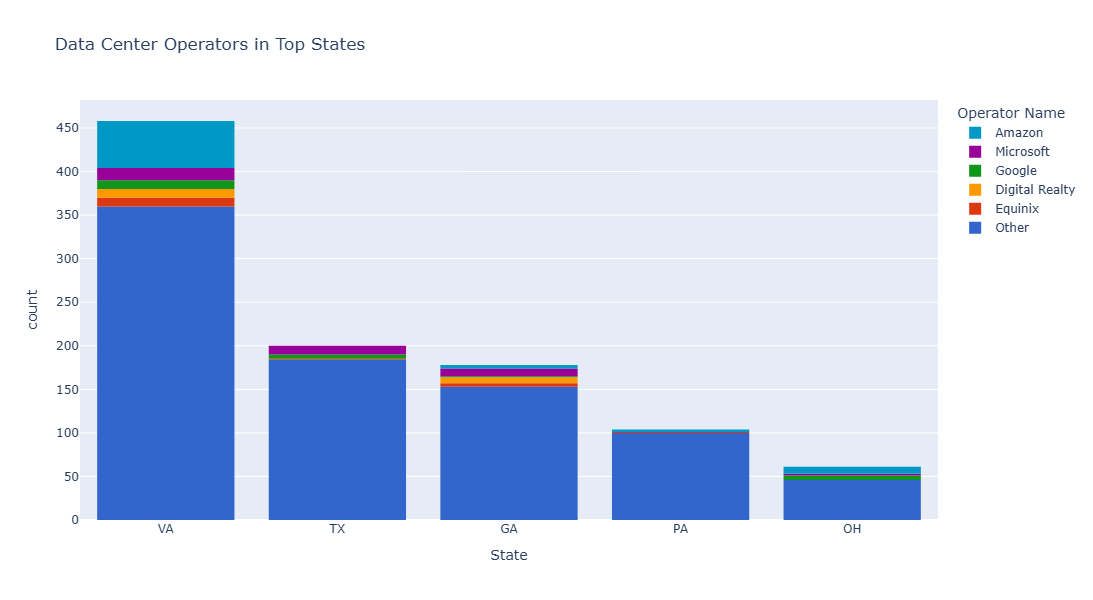

In [109]:
# Plotly version
# https://community.plotly.com/t/countplot-with-plotly-express/45781/7
fig = px.histogram(df_top_states, x = "state", color = "operator_name", 
                   category_orders = {"state": ["VA", "TX", "GA", "PA", "OH"],
                                     "operator_name": ["Other", "Equinix", "Digital Realty", "Google", "Microsoft", "Amazon"]}, 
                   title = "Data Center Operators in Top States", 
                   labels={
                     "state": "State",
                     "operator_name": "Operator Name"
                   },
                   color_discrete_sequence=px.colors.qualitative.G10,
                   width = 800, height = 600)

fig.update_layout(legend_traceorder="reversed")
fig.show()

## Politics Data
### MIT precinct-level data for Senate

The MIT Election Data + Science Lab on [GitHub](https://github.com/MEDSL/2024-elections-official/tree/main): here, I'll start by looking at the [precinct-level returns for 2024 senate](https://github.com/MEDSL/2024-elections-official/blob/main/2024-senate-county.csv), but there are a lot of different dataset options I could use here (or combine). 

In [5]:
senate24_df = pd.read_csv("./Data/2024-senate-county_MIT.csv")
senate24_df.head(10)

,year,state,state_po,state_fips,state_ic,office,county_name,county_fips,candidate,party_detailed,party_simplified,writein,mode,votes,totalvotes,stage,special,unofficial,version
0,2024,ARIZONA,AZ,4,4,US SENATE,APACHE,4001.0,RUBEN GALLEGO,DEMOCRAT,DEMOCRAT,False,TOTAL,19901,31859,GEN,False,False,2025-11-13
1,2024,ARIZONA,AZ,4,4,US SENATE,APACHE,4001.0,KARI LAKE,REPUBLICAN,REPUBLICAN,False,TOTAL,11283,31859,GEN,False,False,2025-11-13
2,2024,ARIZONA,AZ,4,4,US SENATE,APACHE,4001.0,EDUARDO QUINTANA,GREEN,OTHER,False,TOTAL,675,31859,GEN,False,False,2025-11-13
3,2024,ARIZONA,AZ,4,4,US SENATE,COCHISE,4003.0,RUBEN GALLEGO,DEMOCRAT,DEMOCRAT,False,TOTAL,23347,58093,GEN,False,False,2025-11-13
4,2024,ARIZONA,AZ,4,4,US SENATE,COCHISE,4003.0,KARI LAKE,REPUBLICAN,REPUBLICAN,False,TOTAL,33184,58093,GEN,False,False,2025-11-13
5,2024,ARIZONA,AZ,4,4,US SENATE,COCHISE,4003.0,EDUARDO QUINTANA,GREEN,OTHER,False,TOTAL,1562,58093,GEN,False,False,2025-11-13
6,2024,ARIZONA,AZ,4,4,US SENATE,COCONINO,4005.0,RUBEN GALLEGO,DEMOCRAT,DEMOCRAT,False,TOTAL,42924,69470,GEN,False,False,2025-11-13
7,2024,ARIZONA,AZ,4,4,US SENATE,COCONINO,4005.0,KARI LAKE,REPUBLICAN,REPUBLICAN,False,TOTAL,24825,69470,GEN,False,False,2025-11-13
8,2024,ARIZONA,AZ,4,4,US SENATE,COCONINO,4005.0,EDUARDO QUINTANA,GREEN,OTHER,False,TOTAL,1721,69470,GEN,False,False,2025-11-13
9,2024,ARIZONA,AZ,4,4,US SENATE,GILA,4007.0,RUBEN GALLEGO,DEMOCRAT,DEMOCRAT,False,TOTAL,9330,27327,GEN,False,False,2025-11-13


Looks like for each county/precinct, the dataset contains records for how many votes each candidate in the general election for Senate received (these are statewide elections, but voting percentages could tell us the political leanings of that county). 

Pre-processing required: calculating who won each county.

In [11]:
print("Shape:", senate24_df.shape)
print("Number of states:", senate24_df["state_po"].nunique())
print("Number of counties (approx):", senate24_df["county_name"].nunique()) # does not acount for counties in diff states with same names
print("Number of county FIPS:", senate24_df["county_fips"].nunique()) 

Shape: (9170, 19)
Number of states: 33
Number of counties (approx): 1291
Number of county FIPS: 1876


Issue: does not cover all of the U.S. Could potentially address by grabbing [state-level election results](https://github.com/MEDSL/2024-elections-official/blob/main/2024-senate-state.csv) (from other MIT dataset) when county-level is not available. 

Lots more FIPS than county names, presumably bc county names are often repeated across states. 

From MIT, could also look at state-level returns for [2024 presidential elections](https://github.com/MEDSL/2024-elections-official/blob/main/2024-president-state.csv) to get general idea of political leanings of state, but that's pretty general (believe they also have precinct-level in separate dataset)

MIT also has [data](https://github.com/MEDSL/2024-elections-official/tree/main/individual_states) for all individual states for presidential, US house, state house etc spread across zip files per each state. Could decide if overkill or not. 

### American Local Government Elections Database

From [Nature article](https://www.nature.com/articles/s41597-023-02792-x#Sec6) and [OSF repository](https://osf.io/mv5e6/overview). Published 2023, goes from 1989-2021.

From Nature: "This is the most comprehensive publicly-available source of information on local elections across the country."

**Candidate-level Data**

Note that partisanship and race of many candidates is imputed

In [10]:
local_df = pd.read_csv("./Data/2021_local_politics/ledb_candidatelevel.csv")
local_df.head()

,ledb_candid,full_name,firstname,lastname,fips,geo_name,state_abb,office_consolidated,year,month,...,prob_female,prob_male,gender_est,prob_black,prob_white,prob_hispanic,prob_asian,prob_other,race_est,ballotpedia_url
0,59965,gil garcetti,gil,garcetti,06037,los angeles,CA,Prosecutor,1992,11.0,...,0.03,0.97,M,0.02,0.83,0.14,0.01,0.0,caucasian,NaN
1,59966,george gascon,george,gascon,06037,los angeles,CA,Prosecutor,2020,11.0,...,0.00,1.00,M,0.14,0.72,0.10,0.03,0.0,caucasian,NaN
2,59968,jackie lacey,jackie,lacey,06037,los angeles,CA,Prosecutor,2020,11.0,...,0.51,0.49,F,0.91,0.09,0.00,0.00,0.0,black,NaN
3,59968,jackie lacey,jackie,lacey,06037,los angeles,CA,Prosecutor,2012,11.0,...,0.51,0.49,F,0.91,0.09,0.00,0.00,0.0,black,NaN
4,7904,kim foxx,kim,foxx,17031,cook,IL,Prosecutor,2016,11.0,...,1.00,0.00,F,0.93,0.06,0.00,0.00,0.0,black,NaN


Gives distinct number of notes for each candidate as well as whether each candidate won or lost. Shows distinct contests across time; will need to aggregate results in some way and/or just look at most recent. 

In [16]:
print("Shape:", local_df.shape)
print("Number of states:", local_df["state_abb"].nunique()) 
print("Number of FIPS:", local_df["fips"].nunique()) 

Shape: (126599, 32)
Number of states: 53
Number of FIPS: 2632


In [17]:
local_df["state_abb"].unique()
# needs a little cleaning, e.g. has both "MD" and "Maryland"

array(['CA', 'IL', 'AZ', 'NY', 'TX', 'MI', 'FL', 'MA', 'WA', 'NV', 'OH',
       'NC', 'GA', 'MN', 'CO', 'MO', 'WI', 'MD', 'PA', 'WV', 'UT', 'NJ',
       'KS', 'KY', 'DC', 'HI', 'VA', 'OR', 'AL', 'DE', 'NM', 'IN', 'SC',
       'OK', 'IA', 'NE', 'ID', 'ME', 'TN', 'AR', 'LA', 'NH', 'MS', 'VT',
       'ND', 'MT', 'SD', 'AK', 'RI', 'WY', 'CT', 'Maryland', 'Utah'],
      dtype=object)

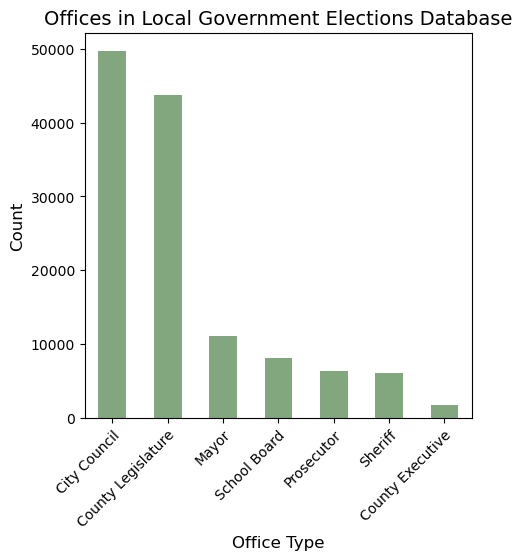

In [49]:
plt.figure(figsize = (5,5))

local_df["office_consolidated"].value_counts().plot(kind = "bar", color = "#82a67d")
plt.title("Offices in Local Government Elections Database", fontsize = 14)
plt.ylabel("Count", fontsize = 12)
plt.xlabel("Office Type", fontsize = 12)
plt.xticks(rotation = 45, rotation_mode = "anchor", ha = "right")
plt.show()

**Constituency-level data**

From Nature: each observation is at the level of a government jurisdiction. These include data for cities (cities_constituency_data.csv), counties (counties_constituency_data.csv), school districts (schools_districts_constituency_data.csv), city council districts (city_council_districts_constituency_data.csv), and county legislative districts (county_leg_districts_constituency_data.csv). 

* cities_constituency_data.csv has demographic information about cities (w. FIPS code), percent voting Dem for pres in 2020
    * Per [data table in Nature](https://www.nature.com/articles/s41597-023-02792-x/tables/3): pres_pctD_20 is Presidential vote shares based on precinct-level data on the 2020 presidential vote
* counties_constituency_data.csv has same as above but for counties 
* city_council_districts_constituency_data.csv: same as above but for individual city council districts
* county_leg_districts_constituency_data.csv: same as above but for individual county legislative districts

So, I think this is going to be less useful, since I can get more recent presidential data elswehere 

### National Neighborhood Data Archive

[National Neighborhood Data Archive (NaNDA)](https://www.icpsr.umich.edu/web/ICPSR/studies/38506#): Voter Registration, Turnout, and Partisanship by County, United States, 2004-2022 (ICPSR 38506)
* Public access but need an account; I signed on through Drexel

Note that we would be limited in how we could share this data

In [32]:
nanda_df = pd.read_csv("./Data/ICPSR_38506/DS0001/38506-0001-Data.tsv", sep = "\t")
nanda_df.head(15)

,STCOFIPS10,YEAR,REG_VOTERS,BALLOTS_CAST,CVAP,REG_VOTERS_PCT,VOTER_TURNOUT_PCT,REG_VOTER_TURNOUT_PCT,PRES_DEM_VOTES,PRES_REP_VOTES,SEN_DEM_VOTES,SEN_REP_VOTES,PRES_DEM_RATIO,PRES_REP_RATIO,SEN_DEM_RATIO,SEN_REP_RATIO,PARTISAN_INDEX_DEM,PARTISAN_INDEX_REP
0,1001,2000,,,,,,,4942,11993,,,.2918216586113,.7081783413887,,,,
1,1001,2002,,,,,,,,,3819,10687,,,.2632703781128,.7367296218872,,
2,1001,2004,28100,20119,34420,.816385805607,.584514796734,.715978622437,4758,15196,3960,15728,.2384484261274,.7615515589714,.2011377513409,.7988622784615,,
3,1001,2006,29724,0,36140,.822468161583,0,0,,,,,,,,,.2582950294018,.7417049407959
4,1001,2008,33536,23714,39580,.847296595573,.599141001701,.707120716572,6093,17403,5316,17941,.2593207359314,.7406792640686,.2285763472319,.771423637867,.2423373311758,.757662653923
5,1001,2010,34727,18180,39580,.877387583256,.45932289958,.523511946201,,,3978,13979,,,.2215292155743,.7784708142281,.2284236103296,.7715764045715
6,1001,2012,37170,24065,39580,.939110636711,.60800909996,.647430717945,6363,17379,,,.2680060565472,.7319939136505,,,.2444946020842,.7555053830147
7,1001,2014,33806,33806,41015,.824235022068,.824235022068,.980000019073,,,0,10345,,,0,1,.1833709478378,.8166290521622
8,1001,2016,38187,25146,41015,.931049644947,.613092780113,.658496320248,5936,18172,6331,18220,.2462253123522,.753774702549,.2578713595867,.742128610611,.1853959113359,.8146041035652
9,1001,2018,39770,19873,44995,.883875966072,.441671282053,.499698251486,,,,,,,,,,


Another way to access pres voting in 2020, but we have access to more recent info 

Most interesting aspects would be turnout and Dem/Rep partisanship index (% votes cast over last six years per downloaded documentation PDF )

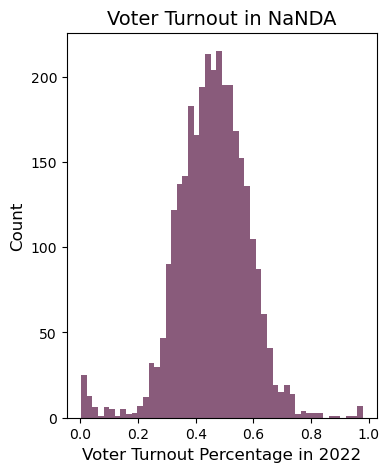

In [51]:
nanda_df_22 = nanda_df[nanda_df["YEAR"] == 2022] # most recent year covered
nanda_turnout_22 = pd.to_numeric(nanda_df_22["VOTER_TURNOUT_PCT"], errors = "coerce")

plt.figure(figsize = (4,5))
nanda_turnout_22[nanda_turnout_22 > 0].hist(bins = 50, grid = False, color = "#895b7b")
# in above, filtering out the -1 

plt.title("Voter Turnout in NaNDA", fontsize = 14)
plt.ylabel("Count", fontsize = 12)
plt.xlabel("Voter Turnout Percentage in 2022", fontsize = 12)
plt.show()

In [52]:
print("Shape for 2022 only:", nanda_df_22.shape)
print("Number of FIPS:", nanda_df_22["STCOFIPS10"].nunique()) 

Shape for 2022 only: (3108, 18)
Number of FIPS: 3108
